In [1]:
# ── 1. KÜTÜPHANELER ───────────────────────────────────────────────────────────

import os
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Mixed precision: float16 hesaplama, float32 ağırlık → VRAM yarıya iner
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print(f"TensorFlow versiyon : {tf.__version__}")
print(f"GPU'lar             : {tf.config.list_physical_devices('GPU')}")

# ─────────────────────────────────────────────────────────────────────────────

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
TensorFlow versiyon : 2.10.0
GPU'lar             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:


# ── 2. AYARLAR ────────────────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent
DATA_DIR    = BASE_DIR / "data"
CLASSES     = ["H1", "H2", "H3", "H5", "H6"]
NUM_CLASSES = len(CLASSES)

IMG_SIZE        = (300, 300)
BATCH_SIZE      = 8
EPOCHS_FROZEN   = 10    # Backbone dondurulmuş; sadece head
EPOCHS_FINETUNE = 20    # Kısmi fine-tune; son 100 katman açık
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4


In [3]:

# ── 3. VERİ YÜKLEYİCİLER ─────────────────────────────────────────────────────

train_ds = image_dataset_from_directory(
    DATA_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

valid_ds = image_dataset_from_directory(
    DATA_DIR / "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# ─────────────────────────────────────────────────────────────────────────────


Found 4780 files belonging to 5 classes.
Found 1022 files belonging to 5 classes.
Found 1029 files belonging to 5 classes.


In [4]:

## Sınıf Dağılımları

splits = {"Train": DATA_DIR / "train", "Valid": DATA_DIR / "valid", "Test": DATA_DIR / "test"}

header = f"{'Sınıf':<8}" + "".join(f"{name:>10}" for name in splits)
print(header)
print("-" * (8 + 10 * len(splits)))

totals = {name: 0 for name in splits}
for cls in CLASSES:
    row = f"{cls:<8}"
    for name, path in splits.items():
        count = len(list((path / cls).glob("*.*")))
        totals[name] += count
        row += f"{count:>10}"
    print(row)

print("-" * (8 + 10 * len(splits)))
print(f"{'TOPLAM':<8}" + "".join(f"{totals[n]:>10}" for n in splits))

Sınıf        Train     Valid      Test
--------------------------------------
H1            1311       281       282
H2            1039       222       224
H3             814       174       175
H5             819       175       176
H6             797       170       172
--------------------------------------
TOPLAM        4780      1022      1029


In [5]:
# ── 4. VERİ ARTIRMA (AUGMENTATION) ───────────────────────────────────────────

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")

# ─────────────────────────────────────────────────────────────────────────────


In [6]:
# ── 5. MODEL — TRANSFER LEARNING (EfficientNetB3) ────────────────────────────

def build_model(trainable_base=False):
    base = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    # EfficientNet kendi içinde normalizasyon yapar; ham [0,255] piksel verilir
    x = base(x, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    return keras.Model(inputs, outputs), base

# ─────────────────────────────────────────────────────────────────────────────


In [7]:

def make_callbacks(save_path):
    return [
        keras.callbacks.ModelCheckpoint(
            save_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,  # JSON serileştirme sorununu önler
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


In [8]:
# ── 7. AŞAMA 1 — DONUK BACKBONE, SADECE HEAD EĞİTİMİ ────────────────────────


print("\n=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===")

model, base_model = build_model(trainable_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary(show_trainable=True)

history_frozen = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=make_callbacks("best_model_efficientnetb3_head.weights.h5"),
)


# ─────────────────────────────────────────────────────────────────────────────



=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===
Model: "model"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_2 (InputLayer)        [(None, 300, 300, 3)]     0         Y          
                                                                            
 augmentation (Sequential)   (None, 300, 300, 3)       0         Y          
                                                                            
 efficientnetb3 (Functional)  (None, 10, 10, 1536)     10783535  N          
                                                                            
 global_average_pooling2d (G  (None, 1536)             0         Y          
 lobalAveragePooling2D)                                                     
                                                                            
 dropout (Dropout)           (None, 1536)              0         Y          
       

In [9]:
# ── 8. AŞAMA 2 — KISMİ FINE-TUNE (son 100 katman) ───────────────────────────

print("\n=== AŞAMA 2: Kısmi Fine-Tune (son 100 katman açık) ===")

# save_weights_only=True kullandığımız için modeli yeniden inşa edip ağırlık yüklüyoruz
model, _ = build_model(trainable_base=False)
model.load_weights("best_model_efficientnetb3_head.weights.h5")
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-100:]:
    layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Açık katman sayısı: {trainable_count} / {len(model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=make_callbacks("best_model_efficientnetb3.h5"),
)


=== AŞAMA 2: Kısmi Fine-Tune (son 100 katman açık) ===
Açık katman sayısı: 6 / 6
Epoch 1/20
598/598 [==============================] - ETA: 0s - loss: 0.7410 - accuracy: 0.7059
Epoch 1: val_loss improved from inf to 0.60184, saving model to best_model_efficientnetb3.h5
598/598 [==============================] - 423s 669ms/step - loss: 0.7410 - accuracy: 0.7059 - val_loss: 0.6018 - val_accuracy: 0.7681 - lr: 1.0000e-04
Epoch 2/20
598/598 [==============================] - ETA: 0s - loss: 0.5389 - accuracy: 0.7839
Epoch 2: val_loss improved from 0.60184 to 0.53589, saving model to best_model_efficientnetb3.h5
598/598 [==============================] - 399s 666ms/step - loss: 0.5389 - accuracy: 0.7839 - val_loss: 0.5359 - val_accuracy: 0.7564 - lr: 1.0000e-04
Epoch 3/20
598/598 [==============================] - ETA: 0s - loss: 0.4679 - accuracy: 0.8151
Epoch 3: val_loss improved from 0.53589 to 0.43097, saving model to best_model_efficientnetb3.h5
598/598 [==============================

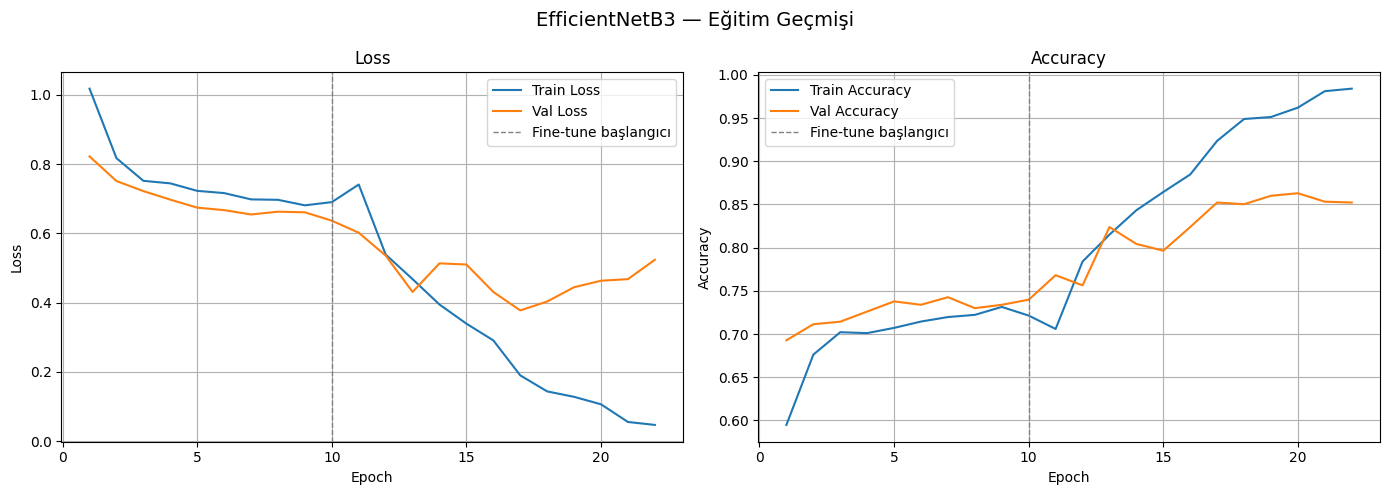

Graf kaydedildi → training_history_efficientnetb3.png


In [12]:
# ── 10. LOSS / ACCURACY GRAFİKLERİ ───────────────────────────────────────────

import matplotlib.pyplot as plt

def plot_history(frozen_hist, finetune_hist):
    train_loss = frozen_hist.history["loss"]         + finetune_hist.history["loss"]
    val_loss   = frozen_hist.history["val_loss"]     + finetune_hist.history["val_loss"]
    train_acc  = frozen_hist.history["accuracy"]     + finetune_hist.history["accuracy"]
    val_acc    = frozen_hist.history["val_accuracy"] + finetune_hist.history["val_accuracy"]

    epochs     = range(1, len(train_loss) + 1)
    frozen_end = len(frozen_hist.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, train_loss, label="Train Loss")
    ax1.plot(epochs, val_loss,   label="Val Loss")
    ax1.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_acc, label="Train Accuracy")
    ax2.plot(epochs, val_acc,   label="Val Accuracy")
    ax2.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.suptitle("EfficientNetB3 — Eğitim Geçmişi", fontsize=14)
    plt.tight_layout()
    plt.savefig("training_history_efficientnetb3.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → training_history_efficientnetb3.png")

plot_history(history_frozen, history_finetune)

In [ ]:
# ── 9. TEST DEĞERLENDİRMESİ ───────────────────────────────────────────────────

print("\n=== Test Değerlendirmesi ===")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
best_model, _ = build_model(trainable_base=False)
best_model.load_weights(Path.cwd() / "best_model_efficientnetb3.h5")
best_model.compile(loss="categorical_crossentropy", metrics=["accuracy"])
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
# ── 11. CONFUSION MATRIX ──────────────────────────────────────────────────────


import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataset, class_names):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
    ax.set_title("Confusion Matrix — EfficientNetB3")
    plt.tight_layout()
    plt.savefig("confusion_matrix_efficientnetb3.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → confusion_matrix_efficientnetb3.png")

    return y_true, y_pred

y_true, y_pred = plot_confusion_matrix(best_model, test_ds, CLASSES)

# ───

In [ ]:
# ── 12. CLASSIFICATION REPORT ─────────────────────────────────────────────────

from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print("\nClassification Report:\n")
print(report)